In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-11-17 17:05:07.731144


# Clustering

### Setup

In [2]:
import os
from pathlib import Path
import scanpy as sc
import numpy as np
from scipy.sparse import issparse, csr_matrix
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import warnings
import session_info
import sys

In [3]:
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning) # Suppress Pandas PerformanceWarnings related to fragmentation

plt.rcParams['figure.figsize'] = (3, 3)

In [4]:
base_dir = Path('/home/workspace/projects/drg')

input_dir = os.path.join(base_dir, 'data/h5ad/export_02/01_scvi')
clusters_dir = os.path.join(base_dir, 'clusters')
output_dir = os.path.join(base_dir, 'data/h5ad/export_02/02_leiden')

os.makedirs(clusters_dir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)

## Read files

In [5]:
sample_files = [
    os.path.join(input_dir, f)
    for f in os.listdir(input_dir)
    if f.endswith(".h5ad")
]

adata_list = [ad.read_h5ad(f) for f in sample_files]

for f, adata in zip(sample_files, adata_list):
    print(f"{os.path.basename(f)} > {adata.n_obs:,} cells × {adata.n_vars:,} genes")

ModelA_whole_all_adata-scvi.h5ad > 97,027 cells × 480 genes
ModelB_whole_noTG_adata-scvi.h5ad > 97,027 cells × 475 genes
ModelD_nuclear_noTG_adata-scvi.h5ad > 97,017 cells × 475 genes
ModelC_nuclear_all_adata-scvi.h5ad > 97,017 cells × 480 genes


## Prepare data

Importing as raw counts layer. Use log1p for rank genes.

In [6]:
for a in adata_list:
    if not issparse(a.X):
        a.X = csr_matrix(a.X)

# verify before + after and update .X to log1p
for a in adata_list:
    print(a.X[:5, :5].toarray())
    print(np.all(a.X.data == np.round(a.X.data)))
    print()
    
    a.X = csr_matrix(a.layers['log1p'].copy())  # keep sparse

    print(a.X[:5, :5].toarray())
    print(np.all(a.X.data == np.round(a.X.data)))
    print("----")

[[ 0.  2.  0.  2.  0.]
 [ 3. 20.  1. 25.  0.]
 [ 1.  1.  5. 13.  0.]
 [ 0.  1.  0.  0.  0.]
 [ 0.  4.  0.  9.  0.]]
True

[[ 0.         8.659507   0.         8.659507   0.       ]
 [ 7.125473   9.021909   6.028468   9.2450285  0.       ]
 [ 6.24855    6.24855    7.85644    8.811713   0.       ]
 [ 0.         7.644289   0.         0.         0.       ]
 [ 0.         9.205453   0.        10.016328   0.       ]]
False
----
[[ 0.  2.  0.  2.  0.]
 [ 3. 20.  1. 25.  0.]
 [ 1.  1.  5. 13.  0.]
 [ 0.  1.  0.  0.  0.]
 [ 0.  4.  0.  9.  0.]]
True

[[ 0.         8.659507   0.         8.659507   0.       ]
 [ 7.125473   9.021909   6.028468   9.2450285  0.       ]
 [ 6.24855    6.24855    7.85644    8.811713   0.       ]
 [ 0.         7.644289   0.         0.         0.       ]
 [ 0.         9.205453   0.        10.016328   0.       ]]
False
----
[[0. 2. 0. 2. 0.]
 [2. 3. 0. 1. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
True

[[0.         8.94044423 0.         8.94044423 0.       

## Neighbors, UMAP, clustering

In [7]:
for adata in adata_list:
    # extract model name from latent key
    latent_key = [k for k in adata.obsm if k.startswith("X_scVI_")][0]
    model_name = latent_key.replace("X_scVI_", "")
    
    # add to obs
    adata.obs["scvi_model"] = model_name
    print(f"Add model {model_name} to obs column `scvi_model`")

for adata in adata_list:
    print(adata.obs["scvi_model"].unique())

Add model ModelA_whole_all to obs column `scvi_model`
Add model ModelB_whole_noTG to obs column `scvi_model`
Add model ModelD_nuclear_noTG to obs column `scvi_model`
Add model ModelC_nuclear_all to obs column `scvi_model`
['ModelA_whole_all']
['ModelB_whole_noTG']
['ModelD_nuclear_noTG']
['ModelC_nuclear_all']


ModelA_whole_all: neighbors/UMAP using X_scVI_ModelA_whole_all


/home/workspace/environment/sc-charter/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_5902/257354825.py:10: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, key_added=leiden_key, resolution=1.0)


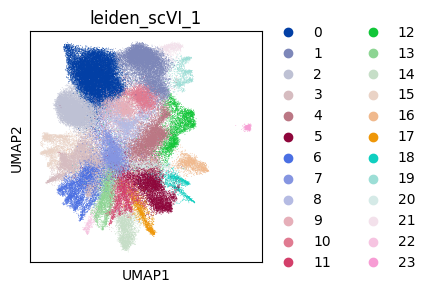

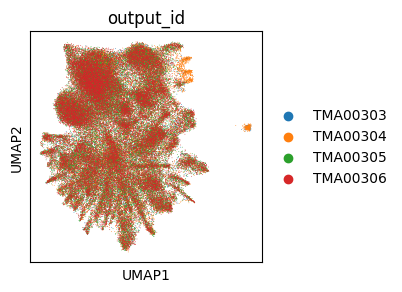

ModelB_whole_noTG: neighbors/UMAP using X_scVI_ModelB_whole_noTG


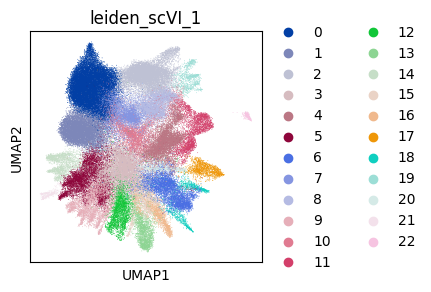

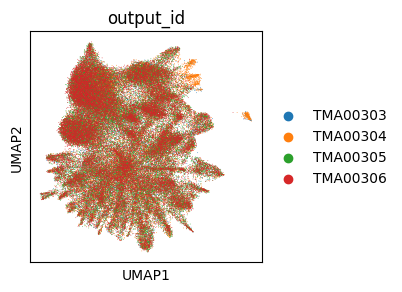

ModelD_nuclear_noTG: neighbors/UMAP using X_scVI_ModelD_nuclear_noTG


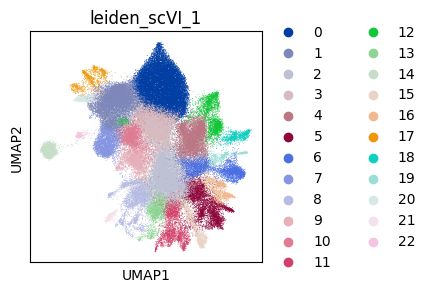

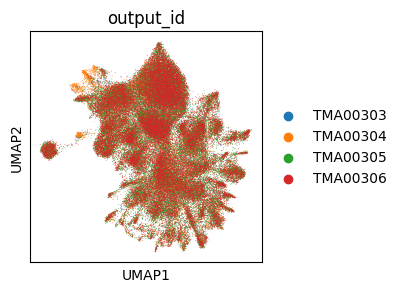

ModelC_nuclear_all: neighbors/UMAP using X_scVI_ModelC_nuclear_all


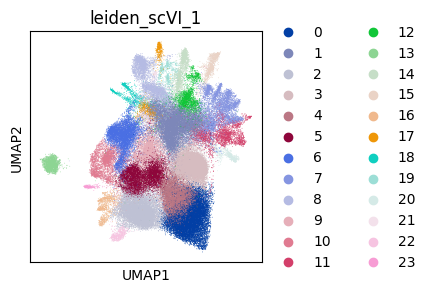

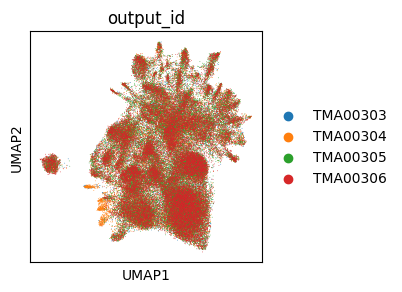

In [8]:
for adata in adata_list:
    latent_key = [k for k in adata.obsm if k.startswith("X_scVI_")][0]
    model_name = adata.obs["scvi_model"].unique()[0]
    leiden_key = "leiden_scVI_1"

    print(f"{model_name}: neighbors/UMAP using {latent_key}")

    sc.pp.neighbors(adata, use_rep=latent_key, random_state=0)
    sc.tl.umap(adata, random_state=0)
    sc.tl.leiden(adata, key_added=leiden_key, resolution=1.0)
    sc.pl.umap(adata, color = ['leiden_scVI_1'])
    sc.pl.umap(adata, color = ['output_id'])

### Run DE rankings on clusters

In [9]:
for adata in adata_list:
    model_name = adata.obs["scvi_model"].unique()[0]
    leiden_key = "leiden_scVI_1"
    
    print(f"\nRunning DE for {model_name} using {leiden_key}")
    
    # Rank genes
    sc.tl.rank_genes_groups(adata, groupby=leiden_key, method='wilcoxon')

    # Extract DE table
    df = sc.get.rank_genes_groups_df(adata, group=None)
    df = df[(df.pvals_adj < 0.05) & (df.logfoldchanges > 0.5)].copy()

    # Save per-model file
    out_path = os.path.join(clusters_dir, f"{model_name}_rank_genes.csv")
    df.to_csv(out_path, index=False)

    print(f"Saved: {out_path}")


Running DE for ModelA_whole_all using leiden_scVI_1
Saved: /home/workspace/projects/drg/clusters/ModelA_whole_all_rank_genes.csv

Running DE for ModelB_whole_noTG using leiden_scVI_1
Saved: /home/workspace/projects/drg/clusters/ModelB_whole_noTG_rank_genes.csv

Running DE for ModelD_nuclear_noTG using leiden_scVI_1
Saved: /home/workspace/projects/drg/clusters/ModelD_nuclear_noTG_rank_genes.csv

Running DE for ModelC_nuclear_all using leiden_scVI_1
Saved: /home/workspace/projects/drg/clusters/ModelC_nuclear_all_rank_genes.csv


In [10]:
for adata in adata_list:
    model_name = adata.obs["scvi_model"].unique()[0]
    out_path = os.path.join(output_dir, f"{model_name}_clustered.h5ad")
    
    adata.write_h5ad(out_path, compression="gzip")
    print("Saved:", out_path)

Saved: /home/workspace/projects/drg/data/h5ad/export_02/02_leiden/ModelA_whole_all_clustered.h5ad
Saved: /home/workspace/projects/drg/data/h5ad/export_02/02_leiden/ModelB_whole_noTG_clustered.h5ad
Saved: /home/workspace/projects/drg/data/h5ad/export_02/02_leiden/ModelD_nuclear_noTG_clustered.h5ad
Saved: /home/workspace/projects/drg/data/h5ad/export_02/02_leiden/ModelC_nuclear_all_clustered.h5ad


### Session info

In [11]:
print('active IDE: sc-charter')
print('active conda environment: ', os.path.basename(sys.prefix))
session_info.show()

active IDE: sc-charter
active conda environment:  sc-charter


/home/workspace/environment/sc-charter/lib/python3.12/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)
